# Break the algorithm — ill-conditioning (Chapter 1)

A condition number bounds worst-case relative sensitivity, not guaranteed digit loss.
Read “The condition number, finally defined” (sec:linalg:conditioning);
continue to duality (Chapter 3), diagnostics (14), and performance/scaling (16).
The experiments hold perturbation direction and relative size fixed before changing
the matrix; a separate comparison holds the matrix fixed and rotates the error.

In [1]:
using LinearAlgebra, Plots, Printf
default(size=(640, 420))

## 1. Two nearly-parallel constraints

Both systems below have exact solution $(1, 1)$. The second differs only
in making the two rows *nearly parallel*.

In [2]:
A_good = [1.0 0.0;0.0 1.0]
A_bad = [1.0 1.0;1.0 1.0000001]
xtrue = [1.,1.]
direction = [1.,-1.] / sqrt(2)  # fixed, deterministic, unit norm
relnoise = 1e-8
for (name,A) in [("well-conditioned",A_good),("ill-conditioned",A_bad)]
    b = A*xtrue
    db = relnoise*norm(b)*direction
    xp = A \ (b+db)
    relb = norm(db)/norm(b)
    relx = norm(xp-xtrue)/norm(xtrue)
    @printf("%-18s kappa=%.2e relative RHS=%.2e relative solution=%.2e bound=%.2e\n",
            name,cond(A),relb,relx,cond(A)*relb)
end

well-conditioned   kappa=1.00e+00 relative RHS=1.00e-08 relative solution=1.00e-08 bound=1.00e-08


ill-conditioned    kappa=4.00e+07 relative RHS=1.00e-08 relative solution=4.00e-01 bound=4.00e-01


Both tests use the same unit error direction and relative RHS magnitude 1e-8.
Only the matrix changes. A normal return from the solve does not certify accurate
input data; compare observed error with the actual relative-error bound.

## 2. Conditioning sweep with a controlled perturbation

Hold direction and relative RHS error at 1e-10 fixed. The bound is
kappa(A) * norm(db)/norm(b), not kappa times an absolute noise amplitude.
Floating-point solution error can add a small arithmetic contribution.

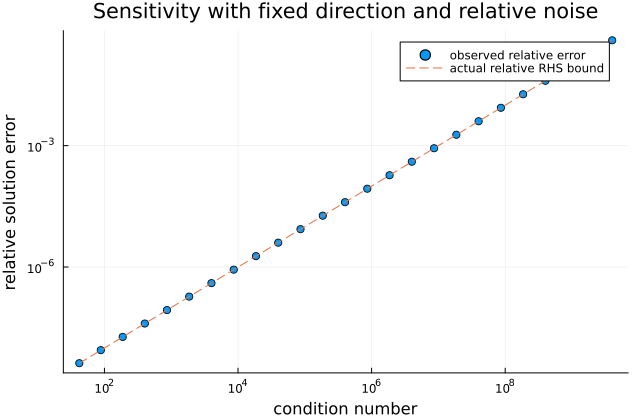

(direction = [1.0, 0.0], relative_RHS = 1.0e-8, relative_solution = 7.071067847220813e-9, bound = 9.999999999999999e-5)
(direction = [0.0, 1.0], relative_RHS = 1.0e-8, relative_solution = 7.071067847220814e-5, bound = 9.999999999999999e-5)


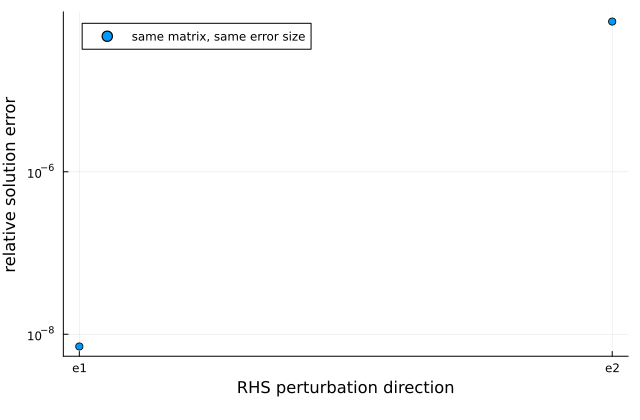

In [3]:
eps_list = 10.0 .^ range(-1,-9;length=25)
conds,errs,bounds = Float64[],Float64[],Float64[]
for e in eps_list
    A = [1.0 1.0; 1.0 (1.0 + e)]
    local xtrue = [1.,1.]
    b = A*xtrue
    db = 1e-10*norm(b)*direction
    xp = A \ (b+db)
    push!(conds,cond(A))
    push!(errs,norm(xp-xtrue)/norm(xtrue))
    push!(bounds,cond(A)*norm(db)/norm(b))
end
pbound=scatter(conds,errs;xscale=:log10,yscale=:log10,label="observed relative error",
              xlabel="condition number",ylabel="relative solution error",
              title="Sensitivity with fixed direction and relative noise")
plot!(pbound,conds,bounds;ls=:dash,label="actual relative RHS bound")
display(pbound)

# Hold A fixed and rotate only the error direction.
A = Diagonal([1.,1e-4])
xtrue = [1.,1.]
b = A*xtrue
errors = Float64[]
for direction_i in ([1.,0.],[0.,1.])
    db = 1e-8*norm(b)*direction_i
    dx = A \ db  # exact perturbation equation; avoids subtractive cancellation
    relx = norm(dx)/norm(xtrue)
    push!(errors,relx)
    println((direction=direction_i,relative_RHS=norm(db)/norm(b),
             relative_solution=relx,bound=cond(A)*norm(db)/norm(b)))
end
@assert errors[2]/errors[1] ≈ 1e4
display(scatter([1,2],errors;yscale=:log10,xticks=([1,2],["e1","e2"]),
                xlabel="RHS perturbation direction",
                bottom_margin=6 * Plots.mm,
                label="same matrix, same error size",ylabel="relative solution error"))


In the direction plot, e1=(1,0) perturbs only the first RHS component and e2=(0,1) perturbs only the second. Both have the same relative RHS error and use A=diag(1,10⁻⁴). The inverse scales the second component by 10⁴, explaining the observed error ratio; the condition-number bound is the same for both directions.

## 3. Exactly singular: rank deficiency

At $\varepsilon = 0$ the matrix is *rank 1*: the system has either no
solution or infinitely many. What does the computer do?

In [4]:
A = [1.0 1.0; 1.0 1.0]
b_incons = [2.0, 3.0]     # inconsistent
b_cons   = [2.0, 2.0]     # consistent: line of solutions x1 + x2 = 2
@show rank(A)
x_ls = pinv(A) * b_incons       # least-squares "answer" to an unsolvable system
@show x_ls, norm(A * x_ls - b_incons)
x0 = pinv(A) * b_cons           # minimum-norm solution among infinitely many
n  = nullspace(A)[:, 1]
@show x0, A * (x0 + 5n) ≈ b_cons

rank(A) = 

1
(x_ls, norm(A * x_ls - b_incons)) = 

([1.2499999999999998, 1.2499999999999996], 0.7071067811865476)


(x0, A * (x0 + 5n) ≈ b_cons) = ([0.9999999999999998, 0.9999999999999997], true)


([0.9999999999999998, 0.9999999999999997], true)

## 4. What to remember for optimization solvers

- A basis solve is a square linear system; near dependence and poor scaling can
  make its solution sensitive. Degeneracy alone is not a condition-number test.
- Scaling and stable factorization address arithmetic; data uncertainty is a
  separate limit. See Chapters 3 (duals), 14 (diagnostics), and 16 (performance).
- Do not remove near-parallel constraints solely to improve a condition number.
  Verify that any reformulation preserves the intended physical feasible set.
- Use absolute and relative feasibility checks in their declared units.

**Experiment:** change relative noise from 1e-10 to 1e-6, preserving the same direction.
Predict how the actual bound moves before running. It bounds error; it does not
force every observed solve to attain it.